In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.metrics import confusion_matrix

In [5]:
X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [6]:
best_model = joblib.load(
    "../models/random_forest.pkl"
)

In [7]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": best_model.feature_importances_
})

In [8]:
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [9]:
top10 = feature_importance.head(10)

top10

,Feature,Importance
5,time_since_signup,0.704382
7,day_of_week,0.053386
6,hour_of_day,0.028613
1,age,0.022561
0,purchase_value,0.021265
187,country_United States,0.020871
4,upper_bound_ip_address,0.019117
2,ip_address,0.019079
3,lower_bound_ip_address,0.017911
16,sex_M,0.008350


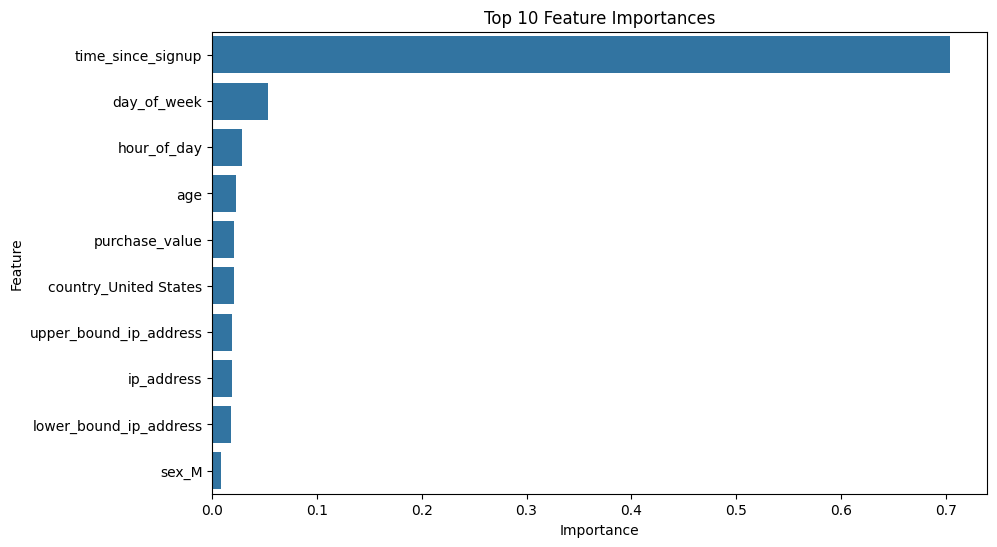

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances"
)

plt.show()

In [11]:
explainer = shap.TreeExplainer(
    best_model
)

In [12]:
# 1. Take a representative sample of 1,000 rows
X_test_sample = X_test.sample(n=1000, random_state=42)

# 2. Re-initialize the explainer
explainer = shap.TreeExplainer(best_model)

# 3. This will now take ~1 minute instead of an hour!
shap_values = explainer.shap_values(X_test_sample)

# 4. Just remember to use the sample when you plot:
# shap.summary_plot(shap_values, X_test_sample)

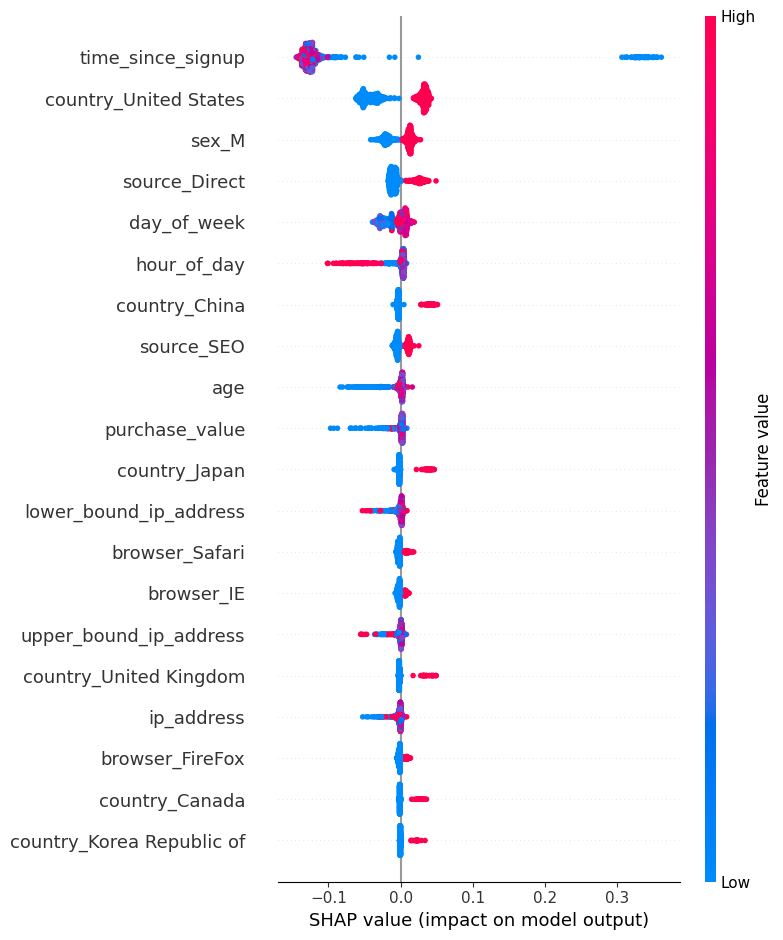

In [15]:
shap.summary_plot(
    shap_values[:, :, 1], 
    X_test_sample  
)

In [16]:
y_pred = best_model.predict(
    X_test
)

In [17]:
tp_idx = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0][0]

In [18]:
fn_idx = np.where(
    (y_test == 1) &
    (y_pred == 0)
)[0][0]

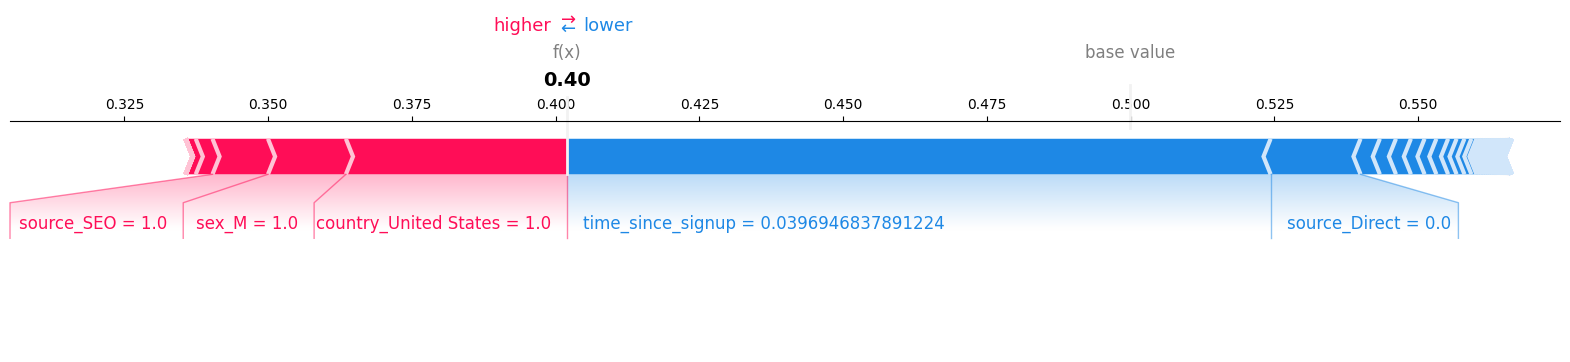

In [20]:
# 1. Grab the SHAP matrix specifically for class 1 (Fraud)
# This converts it into a clean 2D matrix of (samples, features)
shap_values_class1 = shap_values[:, :, 1]

# 2. Plot using the sampled feature data
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[tp_idx],  # Pulls the row from the 2D matrix
    X_test_sample.iloc[tp_idx],  # Matches it to the exact same row in the sample
    matplotlib=True,
)

In [22]:
# 1. Get predictions for your sample
sample_preds = best_model.predict(X_test_sample)

# 2. Align your true labels with the sampled features
y_test_sample = y_test.loc[X_test_sample.index]

# 3. Find all indices where the model guessed Fraud (1) but it was actually Safe (0)
fp_indices = [
    i
    for i, (pred, actual) in enumerate(zip(sample_preds, y_test_sample))
    if pred == 1 and actual == 0
]

# 4. Define fp_idx using the first False Positive found
if fp_indices:
    fp_idx = fp_indices[0]
    print(f"Success! Found a False Positive at sample index: {fp_idx}")
else:
    # Fallback in case your model didn't make any false positive errors in this sample
    fp_idx = 0
    print("No False Positives found in this sample. Defaulting fp_idx to 0.")

Success! Found a False Positive at sample index: 58


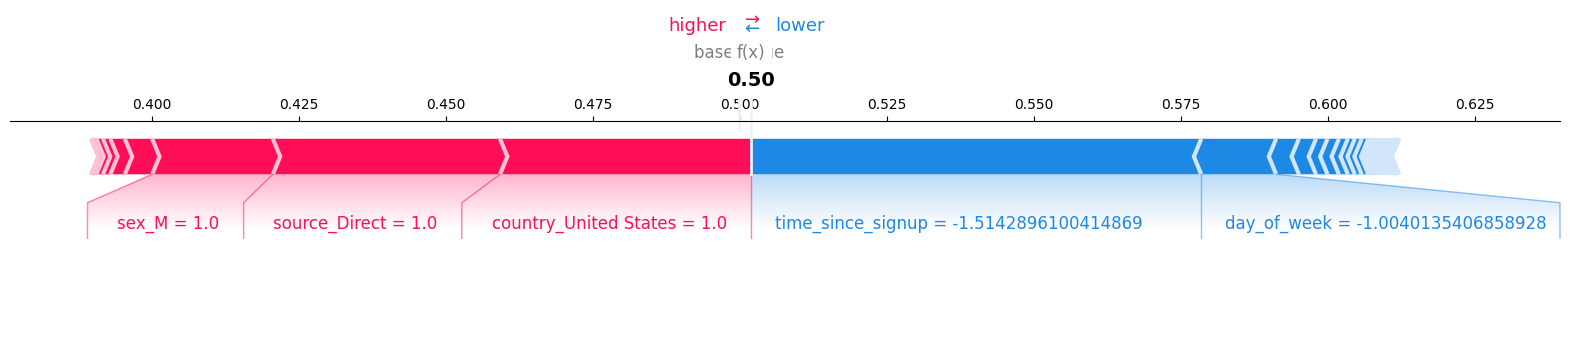

In [23]:
# 1. Use the clean 2D matrix for class 1 (Fraud)
shap_values_class1 = shap_values[:, :, 1]

# 2. Point everything to your sample data pool using fp_idx
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[fp_idx],  # Pulls the FP row from the 2D matrix
    X_test_sample.iloc[fp_idx],  # Matches it to the exact same row in the sample
    matplotlib=True,
)

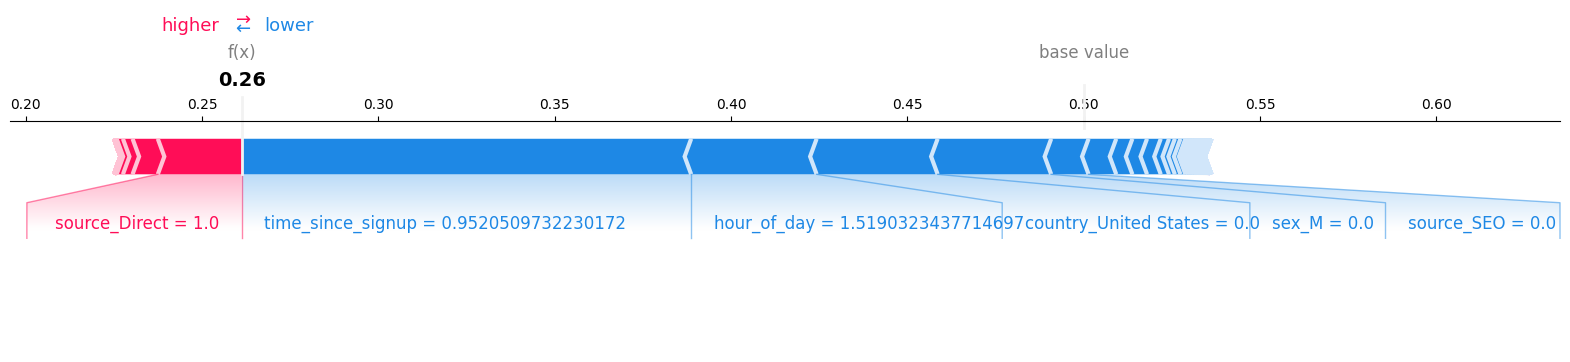

In [24]:
# 1. Isolate the SHAP values for the fraud class (class 1)
shap_values_class1 = shap_values[:, :, 1]

# 2. Plot the force plot for your newly found fn_idx
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[fn_idx],  # Pulls the FN row from the 2D matrix
    X_test_sample.iloc[fn_idx],  # Matches it to the exact same row in the sample
    matplotlib=True,
)

In [25]:
top10.head()

,Feature,Importance
5,time_since_signup,0.704382
7,day_of_week,0.053386
6,hour_of_day,0.028613
1,age,0.022561
0,purchase_value,0.021265
